In [23]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

import numpy as np
import matplotlib.pyplot as plt
import ultranest
from ultranest.plot import cornerplot


In [24]:
from src.parameters import Parameters
from src.acquisition import Acquisition
from src.forward import ForwardSimulation
from src.layers import create_layers


In [25]:
vps_ref = np.array([1500., 1900., 2800., 3800., 2300., 5000.])
hs_ref = np.array([150.0, 200.0, 250.0, 380.0, 440.0, 500.0])
rhos_ref = np.array([2000.0, 2000.0, 2000.0, 2000.0, 2000.0, 2000.0])
layers_ref = create_layers(hs_ref, vps_ref, rhos_ref)


In [26]:
# configuration
fs = False
total_time = 2.0    # seconds
f0 = 5.0            # Ricker central frequency (Hz)
f_max = 8.0 * f0    # practical Ricker cutoff
# Nyquist frequency for f_max
dt = 1/(2.*f_max)
nfft = 2**int(np.ceil(np.log2(total_time/dt)))
nfft *= 2 # zero-padding to ensure late wrap-around
nt = int(total_time / dt) + 1
param = Parameters(total_time=total_time, nt=nt, f0=f0, nfft=nfft, epsilon=0.5)
# acquisition
sources = [(30., 76.)]
Nr = 32 # 
x_receivers = np.linspace(100.0, 4000.0, Nr)

receivers = [(x, 76.0) for x in x_receivers]
#Nr=2
#receivers = [(1000., 76.0), (2000.0, 76.)]
#x_receivers = np.array([1000., 2000.])
acq = Acquisition(sources, receivers)
nquad = 64


In [27]:
d_obs = forward(layers_ref, acq, param, nq_prop=nquad, free_surface=fs)

ampli = np.sqrt(np.mean(d_obs**2))
noise_level = 0.1 #0.001  # 1% noise
std_noise = noise_level * ampli

print('max trace ampli = ', ampli)
d_obs_noise = np.zeros(d_obs.shape)
noise = np.random.normal(
        loc=0.0,
        scale=std_noise,
        size=d_obs.shape
    )
d_obs_noise = d_obs + noise


max trace ampli =  0.009501848537199688


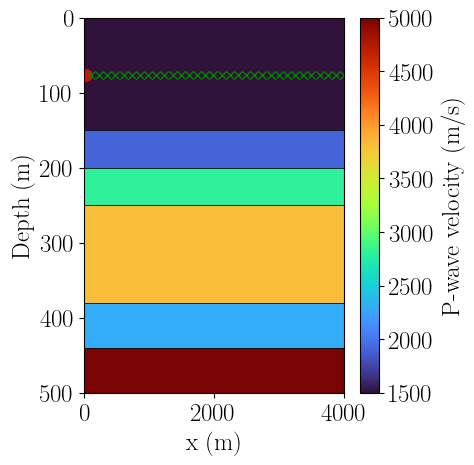

In [28]:
from src.plot.plot_tools import plot_layered_config
plot_layered_config(layers_ref, xrecvs=acq.xr, xs=sources, cmap='turbo')
#plt.savefig('layered_config.png', dpi=300)


(32, 161)


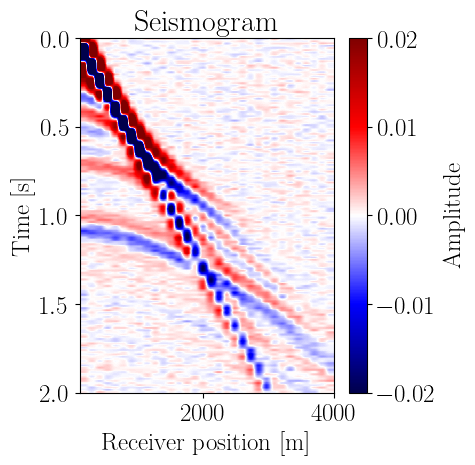

In [29]:
from src.plot.plot_tools import plot_wiggle_traces, plot_seismogram
#plot_wiggle_traces(d_obs_noise[0, :, :], xrecvs=x_receivers, time=param.time, trace_step=1, scale=10.)
print(d_obs[0, :, :].shape)
plot_seismogram(d_obs_noise.T, x_receivers, param.time, vmin=-0.02, vmax=0.02, ncolors=256, figsize=(5,5))


In [30]:
from scipy.linalg import cho_factor, cho_solve

# Number of layers
n_layers = len(vps_ref)
# Prior parameters
mu = np.array([2000., 2500., 2500., 3000., 3000.])
sigma = np.array([1000., 1500., 1500., 1500., 1500.])
cov = np.diag(sigma**2)
chol = cho_factor(cov)


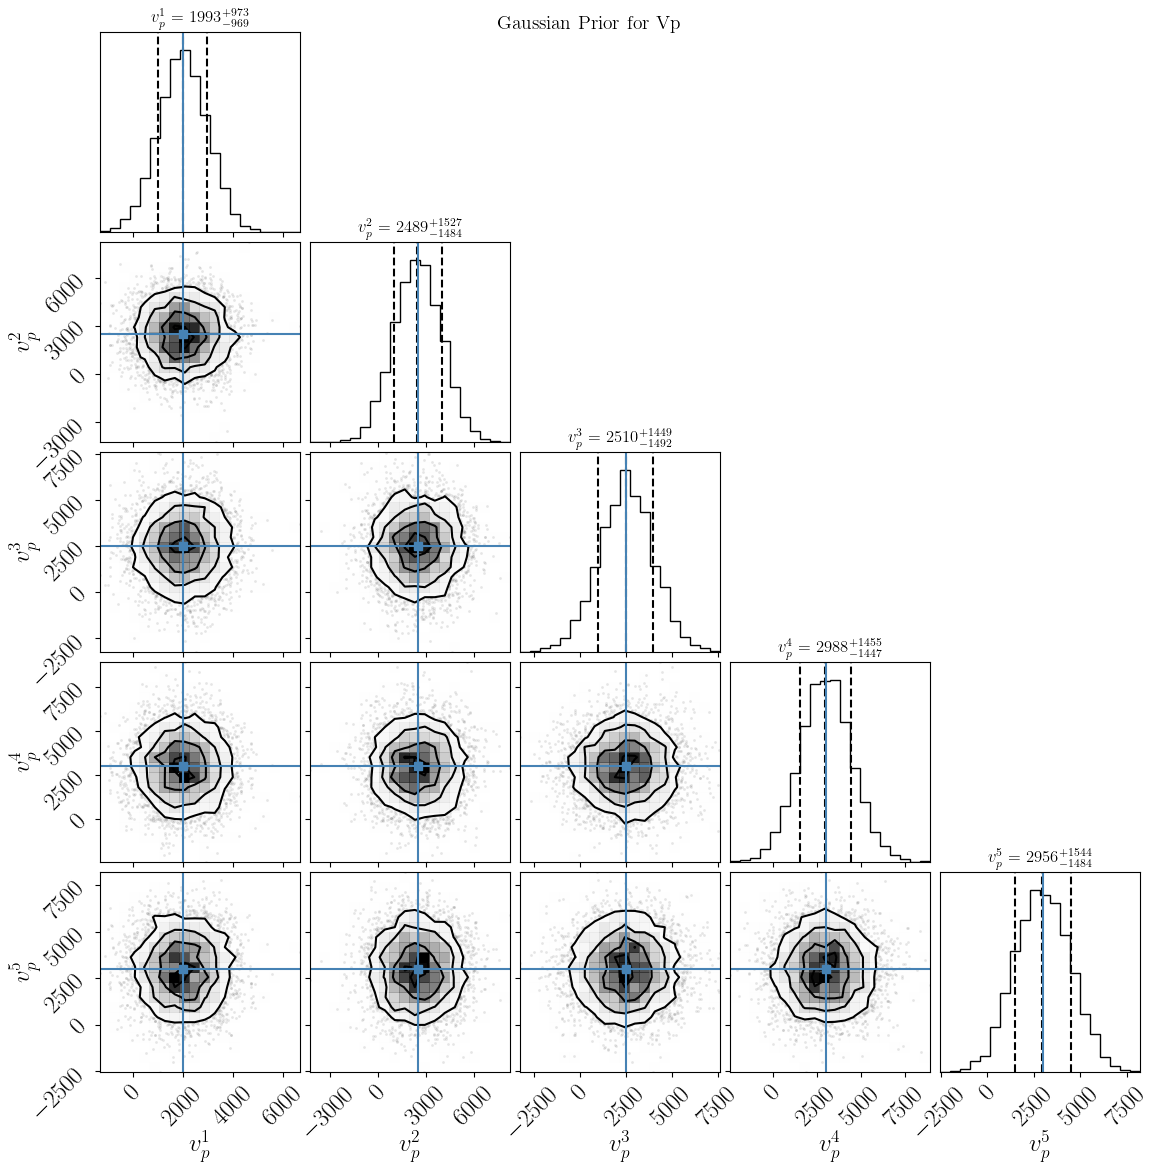

In [31]:
import corner
# Draw 5000 samples from the prior
n_samples = 5000
vp_samples = np.random.multivariate_normal(mu, cov, size=n_samples)

# Create corner plot
figure = corner.corner(
    vp_samples,
    labels=[f"$v_p^{i+1}$" for i in range(n_layers)],
    truths=mu,
    show_titles=True,
    title_fmt=".0f",
    quantiles=[0.16, 0.5, 0.84],
    title_kwargs={"fontsize": 12}
)
figure.suptitle("Gaussian Prior for Vp", fontsize=14)
plt.show()


In [32]:
def l2_misfit(dcal, dobs, std_noise):
    std_noise_eff = std_noise
    return 0.5 * np.sum((dcal - dobs)**2) / (std_noise_eff**2)

def log_likelihood(vp):
    vp_new = np.concatenate((vps_ref[0], vp), axis=None)
    layers_new = create_layers(hs=hs_ref, vps=vp_new, rhos=rhos_ref)
    d_cal = forward(layers_new, acq, param, nq_prop=nquad, free_surface=fs)
    log_like = -l2_misfit(d_cal, d_obs_noise, std_noise=std_noise)
    return log_like

def log_prior(vp):
    diff = vp - mu
    return -0.5 * diff @ cho_solve(chol, diff)

# diagnostics
vp = np.array([6000., 6000., 6000.0, 6000., 6000.])
print(log_likelihood(vp))
print(log_prior(vp))
ratio = log_likelihood(vp)/log_prior(vp)
print(ratio)
vp = np.array([2000., 3800., 2800., 4300., 5500.])
print(log_likelihood(vp))
print(log_likelihood(vps_ref[1:]))


-93919.90137924177
-17.444444444444443
5383.943391166726
-49029.68290850305
-2608.305982131772


In [33]:
def log_posterior(vp, val):
    return log_prior(vp) + log_likelihood(vp)/val

vp0 = mu.copy()
print(vp0)
print("log_prior(mu):", log_prior(vp0))
print("log_likelihood(mu):", log_likelihood(vp0))
print("log_post(mu):", log_posterior(vp0, ratio))

vp_test = mu + sigma   # one standard deviation perturbation
print("log_prior(mean + sigma):", log_prior(vp_test))
print("log_likelihood(mean + sigma):", log_likelihood(vp_test))
print("log_post(mean + sigma):", log_posterior(vp_test, ratio))
# reference
print("log_likelihood(true):", log_likelihood(vps_ref[1:]))
print("log_post(true):", log_posterior(vps_ref[1:], ratio))


[2000. 2500. 2500. 3000. 3000.]
log_prior(mu): 0.0
log_likelihood(mu): -23750.187801824883
log_post(mu): -4.411299688029986
log_prior(mean + sigma): -2.5
log_likelihood(mean + sigma): -78687.50149011293
log_post(mean + sigma): -17.11521709518959
log_likelihood(true): -2608.305982131772
log_post(true): -1.8827934757655775


In [34]:
def my_prior_transform(cube):
    params = cube.copy()
    # transform location parameter: uniform prior
    lo = 1000
    hi = 7000
    for i in range(len(params)):
        params[i] = cube[i] * (hi - lo) + lo
    return params
    
def my_likelihood(params):
    c1, c2, c3, c4, c5 = params
    c = np.array([c1, c2, c3, c4, c5])
    return log_posterior(c, val=ratio/8.)


In [35]:
param_names = ['v1', 'v2', 'v3','v4', 'v5']
sampler = ultranest.ReactiveNestedSampler(param_names, my_likelihood, my_prior_transform)
result = sampler.run(min_ess=500, min_num_live_points=300)


[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-5  11 [-5.3980..-5.3968]*| it/evals=6383/47840 eff=13.4266% N=300      
[ultranest] Likelihood function evaluations: 47840
[ultranest]   logZ = -21.97 +- 0.1524
[ultranest] Effective samples strategy satisfied (ESS = 2362.0, need >500)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.


In [36]:
#import pickle
#filename = 'results_ultranest_sharp'
#with open(filename + '.pkl', 'wb') as fp:
#    pickle.dump(result, fp)
#    print("results saved !")
sampler.print_results()



logZ = -21.978 +- 0.349
  single instance: logZ = -21.978 +- 0.212
  bootstrapped   : logZ = -21.967 +- 0.349
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    v1                  : 1834  │ ▁▁▁ ▁▁▁▁▁▂▂▃▃▄▆▆▇▇▇▇▇▅▆▄▄▃▂▂▁▁▁▁▁▁  ▁ │1965      1900 +- 16
    v2                  : 2572  │ ▁▁▁▁▁▁▁▂▃▄▄▆▇▇▇▆▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁  ▁ │3177      2809 +- 62
    v3                  : 2846  │ ▁   ▁▁▁▁▂▂▄▅▇▇▇▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁  ▁▁▁ │5261      3811 +- 212
    v4                  : 1000  │ ▁▁▁▁▁▁▁▁▆▇▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁      ▁ │6073      2383 +- 307
    v5                  : 1000  │▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▃▄▅▆▇▇▆▇▇▆▅▄▄▄▂▂▁▁▁▁▁▁▁▁│7000      4184 +- 970



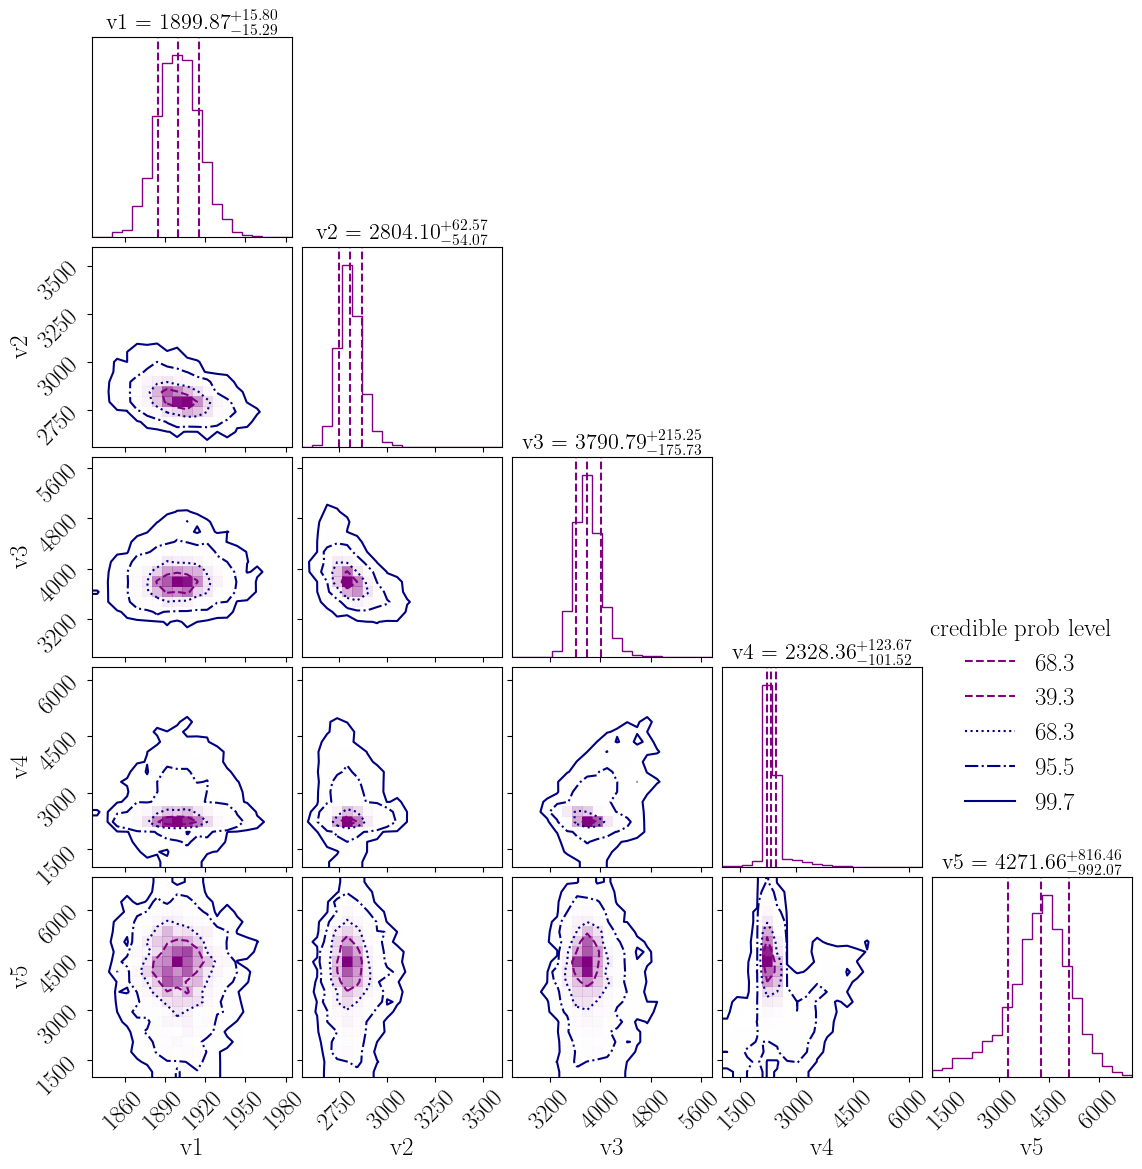

In [37]:
vps_true = np.array([1900., 2800., 3800., 2300., 5000.])
figure = cornerplot(result, plot_density=True, title_kwargs={"fontsize": 16})
plt.show()


In [38]:
from ultranest.plot import PredictionBand
band1 = PredictionBand(param.time)
band4 = PredictionBand(param.time)
ns = len(sampler.results['samples'])
# go through the solutions
for vp1, vp2, vp3, vp4, vp5 in sampler.results['samples'][0:ns:10]:
    # compute for each time the y value
    VP = np.array([vps_ref[0], vp1, vp2, vp3, vp4, vp5])
    lays = create_layers(hs=hs_ref, vps=VP, rhos=rhos_ref)
    dcal = forward(lays, acq, param, nq_prop=nquad, free_surface=fs)
    band1.add(dcal[0, 1, :])
    band4.add(dcal[0, 4, :])


(-0.02, 0.02)

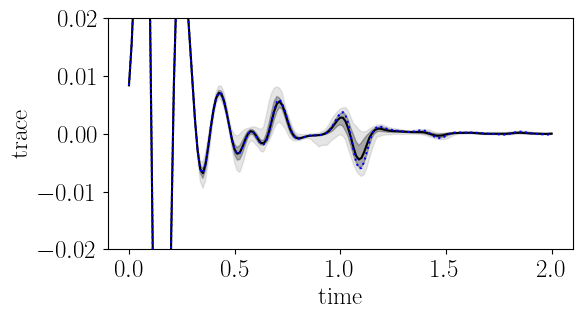

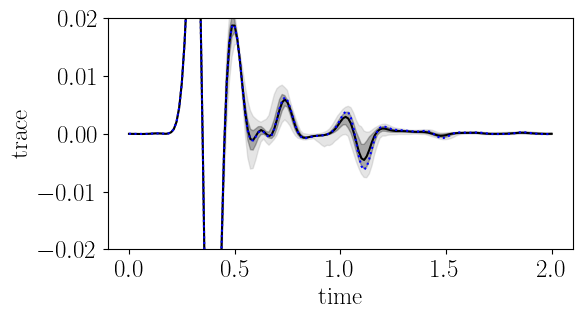

In [39]:
plt.figure(figsize=(6,3))
plt.xlabel('time')
plt.ylabel('trace')
band1.line(color='k')
band1.shade(color='k', alpha=0.3)
band1.shade(q=0.49, color='gray', alpha=0.2)
plt.plot(param.time, d_obs[0, 1, :], 'b:')
plt.ylim([-0.02,0.02])


plt.figure(figsize=(6,3))
plt.xlabel('time')
plt.ylabel('trace')
band4.line(color='k')
band4.shade(color='k', alpha=0.3)
band4.shade(q=0.49, color='gray', alpha=0.2)
plt.plot(param.time, d_obs[0, 4, :], 'b:')
plt.ylim([-0.02,0.02])
